# Módulo 1 — Motor Cuantitativo y Optimización de Markowitz (Producción)

**Sistema Web de Optimización de Portafolio (Streamlit)**

Este notebook constituye la capa de acceso a datos y el núcleo de optimización matemática del proyecto. Descarga el histórico del universo definido (mineras con operaciones en Perú), procesa la matriz de covarianza y el vector de retornos, inyecta programáticamente un activo libre de riesgo (CASH) y resuelve los portafolios óptimos usando programación cuadrática (SLSQP).

In [87]:
# Instalación de dependencias (solo si es necesario en el entorno)
!pip install yfinance openpyxl matplotlib scipy --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42) # Semilla para reproducibilidad de la frontera eficiente
print("Dependencias cargadas correctamente.")

Dependencias cargadas correctamente.


## 1. Configuración de Entorno y Variables Globales
Se establecen los parámetros base requeridos por el proyecto.

In [88]:
# Parámetros del Universo de Inversión
TICKERS = ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
START_DATE = '2015-01-01'
END_DATE = '2024-12-31'
CAPITAL_INICIAL = 100000.0

# Parámetros Cuantitativos
DIAS_ANIO = 252
RF_RATE = 0.02  # Retorno anualizado del activo CASH (2%)

print(f"Universo Base : {TICKERS}")
print(f"Tasa RF (CASH): {RF_RATE*100}% anual")

Universo Base : ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']
Tasa RF (CASH): 2.0% anual


## 2. Descarga de Precios y Preprocesamiento
**Complejidad Algorítmica:** La extracción y alineamiento temporal de datos de precios es **$O(N \times T)$**, donde $N$ es el número de tickers (5) y $T$ es el horizonte temporal en días (~2500 días de mercado).

In [89]:
print("Conectando con Yahoo Finance...")
df_prices = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Limpieza y tratamiento de NA (Forward fill para feriados no sincronizados)
df_prices = df_prices.dropna(axis=1, how='all')
df_prices = df_prices.fillna(method='ffill').dropna()

print(f"Dimensiones de la matriz de precios: {df_prices.shape}")

[**********************60%****                   ]  3 of 5 completed

Conectando con Yahoo Finance...


[*********************100%***********************]  5 of 5 completed

Dimensiones de la matriz de precios: (2560, 5)


## 3. Retornos, Covarianzas e Inyección de CASH
Calculamos el vector de retornos esperados ($\mu$) y la matriz de covarianza ($\Sigma$).
Luego, manipulamos algebraicamente ambas estructuras para introducir nuestro activo 'CASH'.

**Complejidad Algorítmica:** El cálculo de la matriz de covarianza tiene una complejidad polinomial de **$O(N^2 \times T)$**.

In [90]:
# Retornos logarítmicos continuos
log_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# Vector mu y matriz Sigma anualizados
mu = log_returns.mean() * DIAS_ANIO
Sigma = log_returns.cov() * DIAS_ANIO

# ================= AJUSTE TÉCNICO: INCLUSIÓN DE CASH =================
TICKERS_EXT = TICKERS + ['CASH']

# 1. Ajuste en Vector Mu
mu['CASH'] = RF_RATE

# 2. Ajuste en Matriz Sigma (Varianza 0, Covarianza 0 con el resto)
Sigma.loc['CASH'] = 0.0
Sigma['CASH'] = 0.0

# 3. Ajuste en histórico de retornos (Para simular simulaciones y Sortino Ratio)
log_returns['CASH'] = RF_RATE / DIAS_ANIO

print("Vector de Retornos Esperados (Anualizado):")
display(mu)

Vector de Retornos Esperados (Anualizado):


,0
Ticker,
ABX.TO,0.071694
BHP,0.080794
BVN,0.024776
FSM,-0.010422
VOLCABC1.LM,-0.114717
CASH,0.020000


## 4. Definición de Métricas y Motor de Optimización
Definimos las funciones de riesgo y retorno. Se implementa explícitamente el **Sortino Ratio**, que evalúa únicamente la volatilidad a la baja (*downside deviation*).

In [91]:
def portfolio_performance(weights, mu, Sigma):
    """Retorna (Rendimiento Esperado Anual, Volatilidad Anual)"""
    p_ret = np.sum(mu * weights)
    p_std = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    return p_ret, p_std

def negative_sharpe_ratio(weights, mu, Sigma, risk_free_rate=0.0):
    p_ret, p_std = portfolio_performance(weights, mu, Sigma)
    return -(p_ret - risk_free_rate) / p_std if p_std > 0 else 0.0

def portfolio_volatility(weights, mu, Sigma):
    """Función objetivo para Mínima Varianza"""
    return portfolio_performance(weights, mu, Sigma)[1]

def calculate_sortino_ratio(weights, historical_returns, risk_free_rate=0.0):
    """Sortino Ratio: Penaliza solo la volatilidad a la baja."""
    port_returns = historical_returns.dot(weights)
    downside_returns = port_returns[port_returns < 0]

    expected_return = port_returns.mean() * DIAS_ANIO
    downside_std = np.sqrt((downside_returns**2).mean()) * np.sqrt(DIAS_ANIO)

    if downside_std == 0: return 0.0
    return (expected_return - risk_free_rate) / downside_std

## 5. Resolución de Portafolios (SLSQP)
Determinamos dos fronteras de decisión importantes:
1. **Portafolio de Máximo Sharpe** (Equilibrio óptimo riesgo/recompensa).
2. **Portafolio de Mínima Varianza** (El portafolio más conservador posible).

In [92]:
num_assets = len(TICKERS_EXT)
args = (mu, Sigma)

# Restricciones de Markowitz (Suma de pesos = 1) y límites (Long-only)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.0, 1.0) for _ in range(num_assets))
init_guess = np.array(num_assets * [1. / num_assets])

# 1. OPTIMIZACIÓN: MÁXIMO SHARPE
opt_sharpe = minimize(negative_sharpe_ratio, init_guess, args=(mu, Sigma, RF_RATE),
                      method='SLSQP', bounds=bounds, constraints=constraints)
pesos_sharpe = opt_sharpe.x
ret_sharpe, vol_sharpe = portfolio_performance(pesos_sharpe, mu, Sigma)
ratio_sharpe_opt = (ret_sharpe - RF_RATE) / vol_sharpe
ratio_sortino_opt = calculate_sortino_ratio(pesos_sharpe, log_returns, RF_RATE)

# 2. OPTIMIZACIÓN: MÍNIMA VARIANZA
opt_minvar = minimize(portfolio_volatility, init_guess, args=args,
                      method='SLSQP', bounds=bounds, constraints=constraints)
pesos_minvar = opt_minvar.x
ret_minvar, vol_minvar = portfolio_performance(pesos_minvar, mu, Sigma)

print("✅ Optimización Completada con éxito.")

✅ Optimización Completada con éxito.


## 6. Visualización: Frontera Eficiente Analítica de Markowitz
Construimos la gráfica del espacio Riesgo-Rendimiento resolviendo matemáticamente el problema de minimización de varianza para **200 niveles de retorno objetivo**.
Esto genera la curva continua ("Frontera Eficiente") en lugar de una simulación aleatoria, mostrando exactamente el límite matemático de los portafolios óptimos.

**Complejidad Algorítmica:** Resolver la frontera analítica con un motor numérico requiere **$O(K \times I \times N^3)$**, donde $K=200$ (los puntos de la grilla), $I$ las iteraciones del SLSQP y $N$ la cantidad de activos.

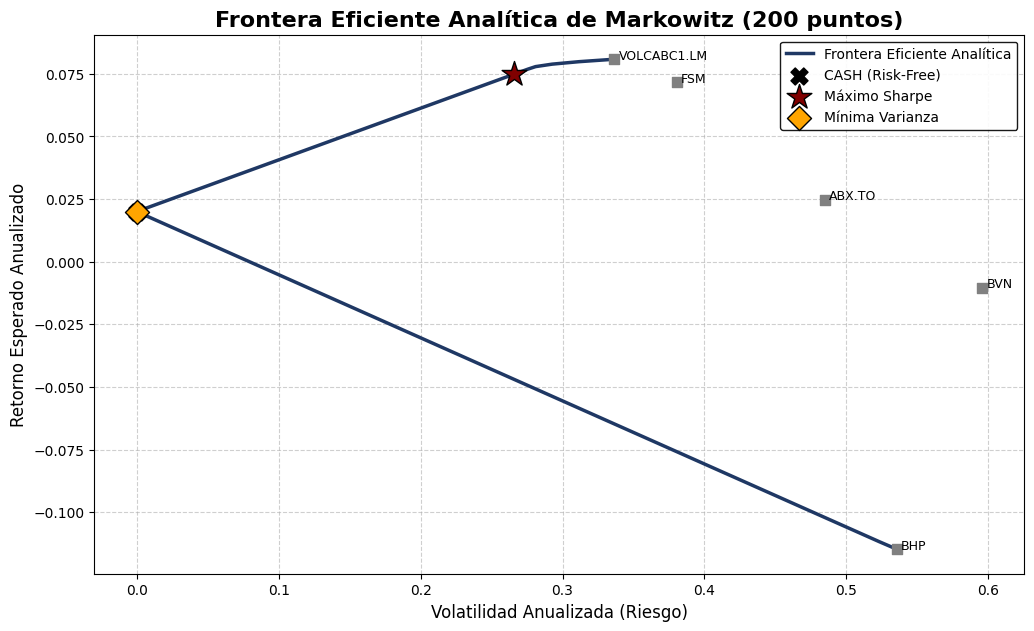

In [93]:
# 1. Generar grilla de 200 retornos objetivo (desde el mínimo hasta el máximo retorno del universo)
target_returns = np.linspace(mu.min(), mu.max(), 200)

efficient_vols = []
efficient_rets = []

# 2. Bucle de Optimización para la Frontera Analítica
for target in target_returns:
    # Restricciones: Suma de pesos = 1 Y Retorno del portafolio = target
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_performance(w, mu, Sigma)[0] - target}
    )
    bnds = tuple((0.0, 1.0) for _ in range(num_assets))

    # Minimizar la volatilidad dado el retorno objetivo
    res = minimize(portfolio_volatility, init_guess, args=(mu, Sigma),
                   method='SLSQP', bounds=bnds, constraints=cons)

    # Solo almacenar si el optimizador encontró una solución factible
    if res.success:
        efficient_vols.append(res.fun)
        efficient_rets.append(target)

# 3. Graficado Profesional
plt.figure(figsize=(12, 7))

# Trazo de la Frontera Eficiente Analítica
plt.plot(efficient_vols, efficient_rets, color='#1F3864', linestyle='-', linewidth=2.5,
         label='Frontera Eficiente Analítica', zorder=2)

# Graficar el activo CASH
plt.scatter(0.0, RF_RATE, color='black', marker='X', s=150, label='CASH (Risk-Free)', zorder=4)

# Graficar Activos Individuales
for i, ticker in enumerate(TICKERS_EXT):
    if ticker != 'CASH':
        vol_individual = np.sqrt(Sigma.iloc[i, i])
        ret_individual = mu.iloc[i]
        plt.scatter(vol_individual, ret_individual, marker='s', color='gray', s=60, zorder=3)
        plt.text(vol_individual + 0.003, ret_individual, ticker, fontsize=9, zorder=3)

# Destacar Portafolios Estratégicos (Cálculos previos de la Sección 5)
plt.scatter(vol_sharpe, ret_sharpe, color='#800000', marker='*', s=350,
            edgecolor='black', label='Máximo Sharpe', zorder=5)
plt.scatter(vol_minvar, ret_minvar, color='orange', marker='D', s=150,
            edgecolor='black', label='Mínima Varianza', zorder=5)

# Configuración de ejes y estética
plt.title('Frontera Eficiente Analítica de Markowitz (200 puntos)', fontsize=16, weight='bold')
plt.xlabel('Volatilidad Anualizada (Riesgo)', fontsize=12)
plt.ylabel('Retorno Esperado Anualizado', fontsize=12)

# Ajuste automático de límites para asegurar la visibilidad de la curva
plt.autoscale(enable=True, axis='both', tight=False)
plt.margins(0.05)

plt.legend(loc='best', framealpha=0.9, edgecolor='black')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 7. Evolución de Riqueza

Analizamos cómo se habría comportado el capital inicial invertido en el portafolio de Máximo Sharpe frente a un portafolio igualmente ponderado en los activos, excluyendo CASH.

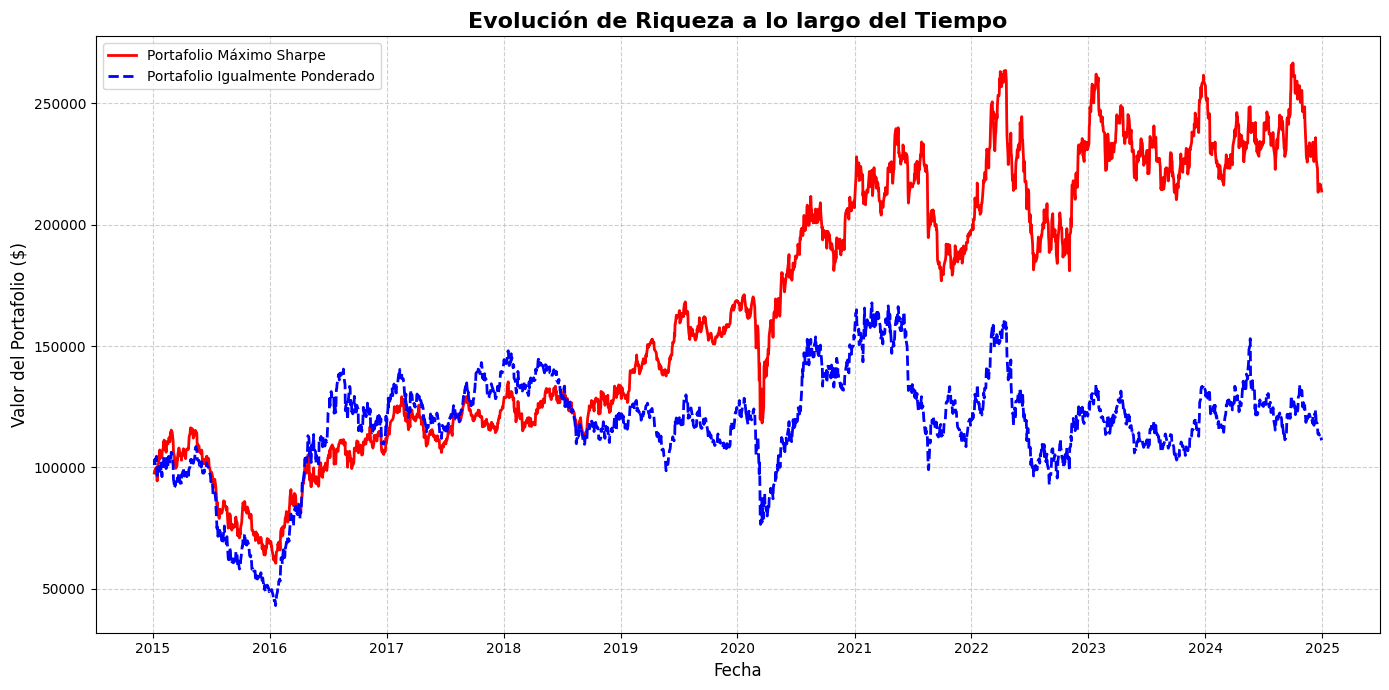

In [94]:
# 1. Retornos Diarios del Portafolio de Máximo Sharpe
sharpe_portfolio_daily_returns = log_returns.dot(pesos_sharpe)

# 2. Retornos Diarios del Portafolio Igualmente Ponderado (Benchmark)
# Excluir 'CASH' para el benchmark de activos reales
num_real_assets = len(TICKERS) # Usar TICKERS original, no TICKERS_EXT
equally_weighted_weights = np.array([1/num_real_assets] * num_real_assets + [0.0]) # Asignar 0 a CASH en este benchmark
equally_weighted_portfolio_daily_returns = log_returns.dot(equally_weighted_weights)

# 3. Cálculo de la Riqueza Acumulada
wealth_sharpe = CAPITAL_INICIAL * np.exp(sharpe_portfolio_daily_returns.cumsum())
wealth_equally_weighted = CAPITAL_INICIAL * np.exp(equally_weighted_portfolio_daily_returns.cumsum())

# 4. Graficado de la Evolución de la Riqueza
plt.figure(figsize=(14, 7))
plt.plot(wealth_sharpe.index, wealth_sharpe, label='Portafolio Máximo Sharpe', color='red', linewidth=2)
plt.plot(wealth_equally_weighted.index, wealth_equally_weighted, label='Portafolio Igualmente Ponderado', color='blue', linestyle='--', linewidth=2)

plt.title('Evolución de Riqueza a lo largo del Tiempo', fontsize=16, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor del Portafolio ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Matriz de Correlación de Retornos

Analizamos la matriz de correlación de los retornos logarítmicos diarios para entender la relación lineal entre los movimientos de los precios de los activos.

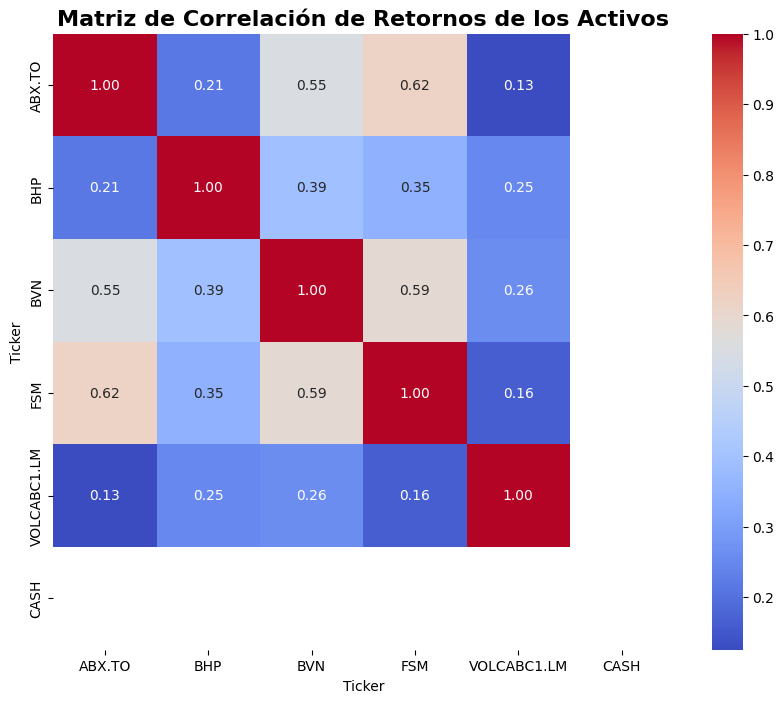

In [95]:
import seaborn as sns

# Calcular la matriz de correlación de los retornos logarítmicos
correlation_matrix_returns = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_returns, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Retornos de los Activos', fontsize=16, weight='bold')
plt.show()

## 9. Exportación de Resultados y Consolidación
Se formatea la salida para ser interpretada directamente por el módulo web. El DataFrame `df_resultados_finales` almacena las métricas individuales por activo y el peso óptimo sugerido por el modelo de Máximo Sharpe.

In [96]:
# Cálculo del Sharpe individual para cada activo
sharpe_individuales = []
volatilidades_individuales = []

for t in TICKERS_EXT:
    v = np.sqrt(Sigma.loc[t, t])
    volatilidades_individuales.append(v)
    if v > 0:
        sharpe_individuales.append((mu[t] - RF_RATE) / v)
    else:
        sharpe_individuales.append(0.0) # CASH tiene Sharpe=0 matemáticamente al no tener riesgo

# Creación del DataFrame de Resultados
df_resultados_finales = pd.DataFrame({
    'Ticker': TICKERS_EXT,
    'Peso_Optimo': pesos_sharpe,
    'Retorno_Esperado': mu.values,
    'Volatilidad_Anual': volatilidades_individuales,
    'Sharpe_Ratio': sharpe_individuales
})

# Ordenar de mayor a menor peso
df_resultados_finales = df_resultados_finales.sort_values(by='Peso_Optimo', ascending=False)
display(df_resultados_finales.style.format({
    'Peso_Optimo': "{:.4%}",
    'Retorno_Esperado': "{:.4%}",
    'Volatilidad_Anual': "{:.4%}",
    'Sharpe_Ratio': "{:.4f}"
}))

# Exportar a Excel requerido por Producción
archivo_salida = 'pesos_optimos_produccion.xlsx'
df_resultados_finales.to_excel(archivo_salida, index=False, engine='openpyxl')
print(f"\n✅ Módulo finalizado. Resultados exportados a '{archivo_salida}'.")
print(f"📊 Sharpe del Portafolio : {ratio_sharpe_opt:.4f}")
print(f"📉 Sortino del Portafolio: {ratio_sortino_opt:.4f}")

,Ticker,Peso_Optimo,Retorno_Esperado,Volatilidad_Anual,Sharpe_Ratio
1,VOLCABC1.LM,60.8489%,8.0794%,53.5502%,-0.2516
0,FSM,34.5584%,7.1694%,59.5593%,-0.0511
5,CASH,4.5927%,2.0000%,0.0000%,0.0000
4,BHP,0.0000%,-11.4717%,33.6491%,0.1807
3,BVN,0.0000%,-1.0422%,48.4992%,0.0098
2,ABX.TO,0.0000%,2.4776%,38.0561%,0.1358



✅ Módulo finalizado. Resultados exportados a 'pesos_optimos_produccion.xlsx'.
📊 Sharpe del Portafolio : 0.2062
📉 Sortino del Portafolio: 0.1991
